In [1]:
# This notebook demonstrates how to use ROSALIA to analyze stray light in a simple exposure. 
import rosalia as rs

# Let's define the minimum parameters to generate a dummy Roman / WFI image
# To get some challenging environment, let's target the Pleiades.
ra = 56.6583333  # Right ascension, in degrees. 
dec = +24.1780556 # Declination, in degrees.
PA = 0 # Position angle, in degrees.
from astropy.time import Time
date = Time("2026-12-01T00:00:00") # Date of the observation, in Astropy Time YYYY-MM-DDTHH:MM:SS format.
bandpass = "F129"
exptime = 600 # Exposure time, in seconds.


observer={"TELESCOP": "Roman/WFI", 
          "pointing": [ra, dec], 
          "FILTER":bandpass, 
          "PA_Y": PA, 
          "EXPSTART": 61192.00000, #  date.mjd, 
          "EXPTIME": exptime}

prefix = "Pleiades"
custom_roman_exposure = rs.core.exposure(observer=observer, prefix=prefix) 

> roman_wfi_exposure


In [2]:
custom_roman_exposure.FILTER_IDENTITY

{'filter_id': 'Roman/WFI.F129',
 'filter_transmission_curve': <Table length=88>
 Wavelength Transmission
  Angstrom       m2     
  float64     float64   
 ---------- ------------
    10800.0       0.0002
    10850.0       0.0007
    10900.0       0.0027
    10950.0       0.0091
    11000.0       0.0267
    11050.0       0.0689
    11100.0       0.1566
    11150.0       0.3153
    11200.0       0.5645
        ...          ...
    14750.0       0.3129
    14800.0       0.1823
    14850.0       0.0988
    14900.0       0.0496
    14950.0       0.0231
    15000.0       0.0099
    15050.0       0.0039
    15100.0       0.0014
    15150.0       0.0005,
 'filter_lambda_ref': <Quantity 12759.98719759 Angstrom>,
 'filter_lambda_min': <Quantity 11050. Angstrom>,
 'filter_lambda_max': <Quantity 14850. Angstrom>,
 'filter_lambda_width': <Quantity 2939.25944471 Angstrom>,
 'filter_transmission_ref': array(2.8308201),
 'wavelength': 'F129',
 'telescope': 'Roman',
 'instrument': 'WFI',
 'detector': 

2026-08-11T15:06:17.663690 > Fetching catalog


18it [00:03,  4.96it/s]

2026-08-11T15:06:21.891224 > Done.
2026-08-11T15:06:21.900891 > Starting Stray-light scan: 



100%|██████████| 18/18 [01:08<00:00,  3.78s/it]


2026-08-11T15:07:31.262516 > Done : 0:01:09.361652 elapsed.
 > Reconstructing the Stray-light / Main offender map: 
2026-08-11T15:07:32.453013 > Done : 


18it [00:00, 545.85it/s]
18it [00:00, 762.81it/s]


2026-08-11T15:07:33.952984 > Drizzling maps... 
2026-08-11T15:39:27.378346 > Done
2026-08-11T15:39:27.386807 > Summary plots... 
Plot: Stray-light surface brightness magnitude.


2026-08-11 15:39:28 WARNING  findfont: Failed to find font weight normal, now using 500.


DEMO WARNING: make_stray_plot is Assuming F129.
25
35


2026-08-11 15:39:28 WARNING  findfont: Failed to find font weight normal, now using 500.


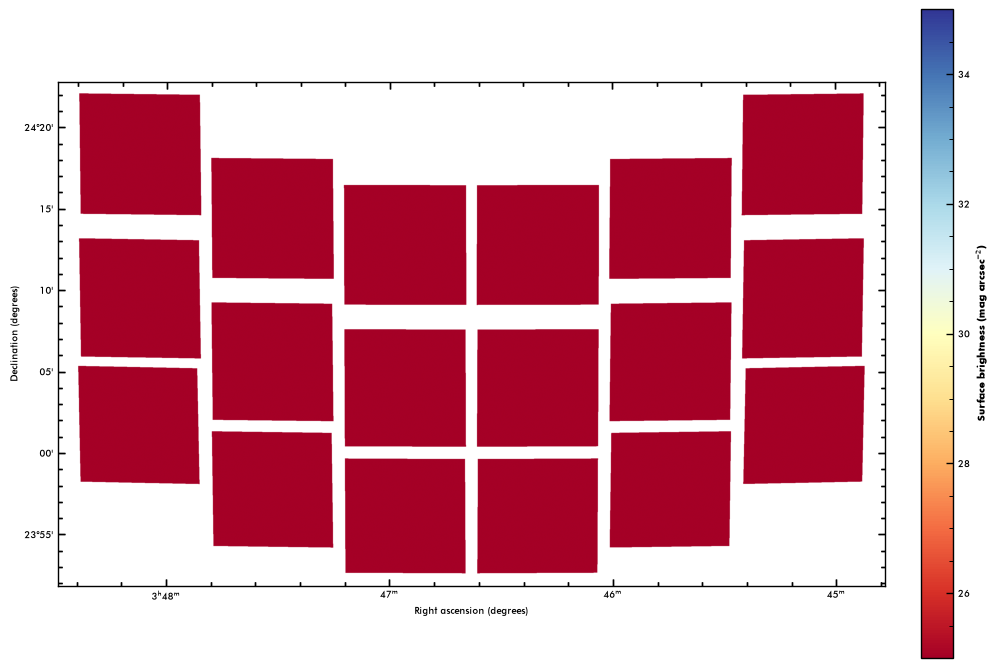

Plot: Stray-light surface brightness flux.
3774995.301328859
5334220.793265425


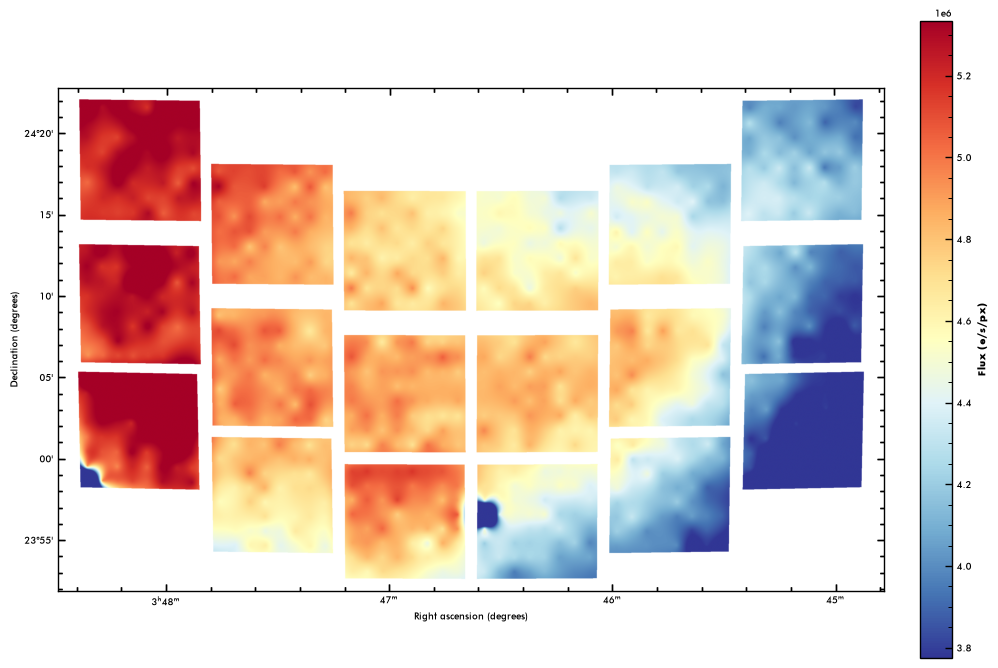

Plot: Main offender map.
1.0
1.0
Unique IDs:
[1]
Unique IDs with counts > 1:
[1]


2026-08-11 15:39:34 WARNING  findfont: Failed to find font weight normal, now using 500.


Simbad cannot find the name of the offender at 68.84425 - 21.92466
Main stray-light offenders:

100.00% - (68.84, 21.92), m=-27.03 - CAT_ID_1


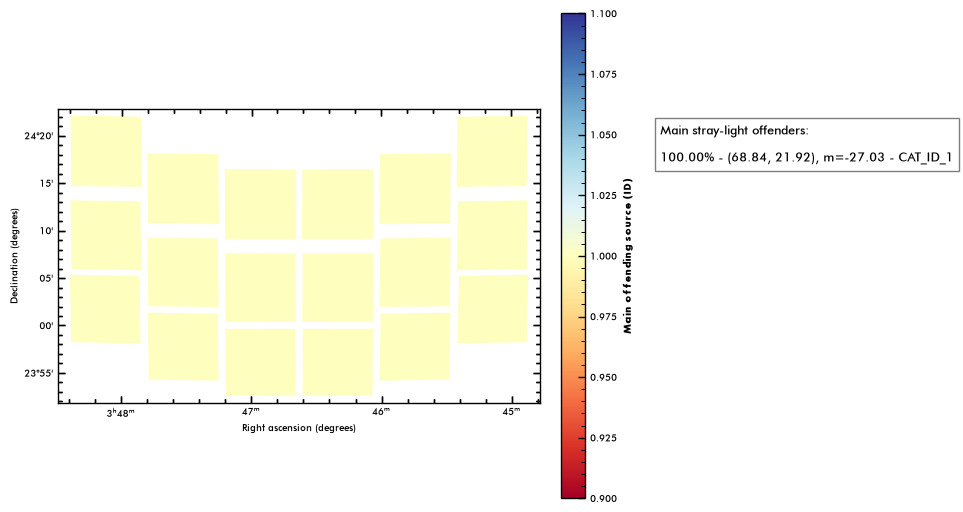

Plot: Source environment map.
SSO body: Sun not found. Skipping
SSO body: Moon not found. Skipping
SSO body: Earth not found. Skipping
SSO body: Mercury not found. Skipping
SSO body: Venus not found. Skipping
SSO body: Mars not found. Skipping
SSO body: Jupiter not found. Skipping
SSO body: Saturn not found. Skipping
SSO body: Uranus not found. Skipping
SSO body: Neptune not found. Skipping
SSO body: Pluto not found. Skipping


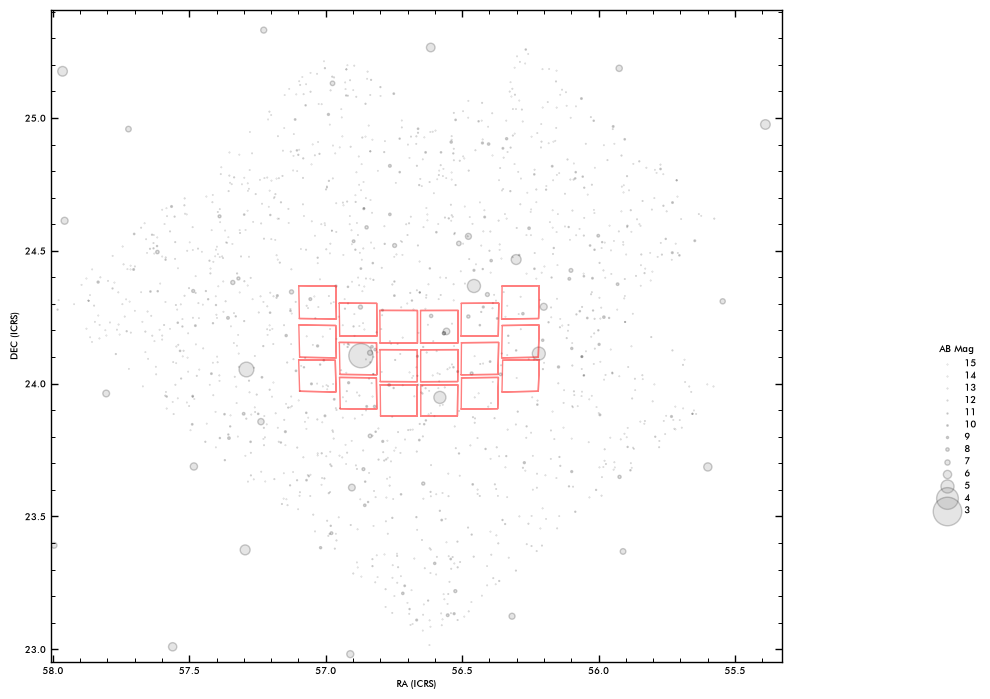

Plot: Location of Main offenders on NDI map.
Unique IDs:
[1]
Unique IDs with counts > 1:
[1]
Simbad cannot find the name of the offender at 68.84425 - 21.92466
Main stray-light offenders:

100.00% - (68.84, 21.92), m=-27.03 - CAT_ID_1
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 56.6583333 24.1780556
CRPIX : 636.5 636.5
NAXIS : 1273  1273


2026-08-11 15:39:36 WARNING  findfont: Failed to find font weight normal, now using 500.


2026-08-11T15:39:39.433927 > Done
Output saved in: /Users/aborlaff/NASA/ROSALIA/notebooks/tutorials/Pleiades_Roman_RA_056.658_DEC_024.178_MJD_61192.00000_PA_000.00_stray.fits
Report saved in: /Users/aborlaff/NASA/ROSALIA/notebooks/tutorials/Pleiades_Roman_RA_056.658_DEC_024.178_MJD_61192.00000_PA_000.00_stray.pdf


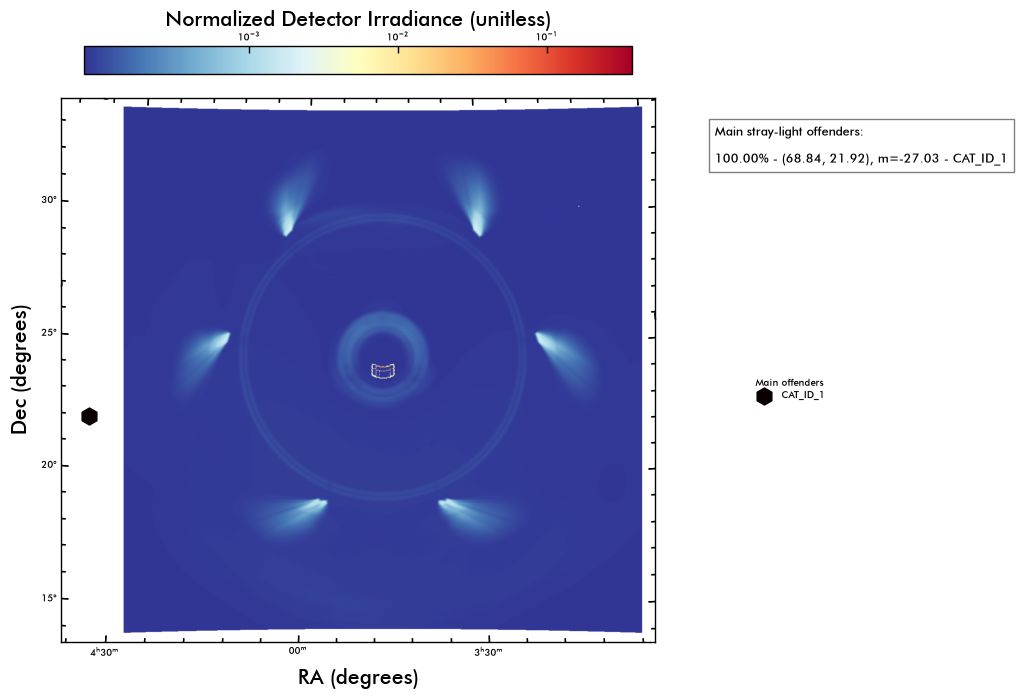

In [3]:
straylevel_all_SCAS = custom_roman_exposure.straylight(g_mag_max=15)

In [4]:
SCA_list = rs.telescopes.Roman.WFI_SCAs
for i in SCA_list:
    print(i)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18


In [5]:
# Benchmarking: 
# 1 - 8:30 min # Original 
# 2 - 6:45     # Using pickled Interpolators and pre calculated Rotators
# 3 - 6:30     # Pre calculating NDI conversion factor 
# 4 - 6:20     # Add all the straylight maps at the end 
# 5 - 3:45     # Parallel analysis per SCA 
# 6 - 3:35     # Parallel drizzling 
# 7 - 3:00     # Linear Interpolation instead of reprojecting.  